## Descarga de la Base de Datos

Los datos de comercio internacional se descargaron de la base de datos del **Atlas de Complejidad Económica** (*Atlas of Economic Complexity*) de la Universidad de Harvard, la cual abarca originalmente el período 1995-2024 con la **clasificación del Sistema Armonizado 1992 (HS92) a nivel de 4 dígitos**.

<u>Fuente:</u> The Growth Lab at Harvard University, 2026, "International Trade Data (HS92)", https://doi.org/10.7910/DVN/T4CHWJ, Harvard Dataverse

<u>Fecha de descarga:</u> 20/05/2026

## Depuración y corte temporal
A partir de la base de datos descargada, se extrajeron exclusivamente los registros correspondientes al año 2024, establecido como el período central de análisis.

In [10]:
import pandas as pd

# Archivo original
input_file = "hs92_country_product_year_4.csv"

# Archivo de salida
excel_output = "hs92_country_product_year_4_2024.xlsx"

# Tamaño de bloques
chunksize = 100000

# Lista para almacenar los bloques filtrados
filtered_chunks = []

# Leer el dataset por partes
for chunk in pd.read_csv(input_file, chunksize=chunksize, low_memory=False, dtype={"product_hs92_code": str}):

    # Filtrar solo año 2024
    filtered_chunk = chunk[chunk["year"] == 2024]

    # Guardar chunk filtrado
    filtered_chunks.append(filtered_chunk)

# Unir todos los resultados
df_2024 = pd.concat(filtered_chunks, ignore_index=True)

# Exportar a Excel
df_2024.to_excel(excel_output, index=False)

print("Archivo generado correctamente.")
print(f"Excel: {excel_output}")
print(f"Total filas año 2024: {len(df_2024)}")

Archivo generado correctamente.
Excel: hs92_country_product_year_4_2024.xlsx
Total filas año 2024: 229759


## Matriz país-producto
Se creó la matriz país-producto, donde:
*   Filas: `country_iso3_code`
*   Columnas: `producto_id`
*   Valores: `export_value`

In [11]:
import pandas as pd

# Archivo de entrada
input_file = "hs92_country_product_year_4_2024.xlsx"

# Archivo de salida
excel_output = "matriz_exportaciones_2024.xlsx"

# Leer dataset
df = pd.read_excel(input_file, dtype={"product_hs92_code": str})

# Crear matriz
matrix = df.pivot_table(
    index="country_iso3_code",    # filas
    columns="product_id",         # columnas
    values="export_value",        # valores
    aggfunc="sum",                # suma si hay duplicados
    fill_value=0                  # reemplaza NaN por 0
)

# Resetear índice para que country_iso3_code quede como columna
matrix.reset_index(inplace=True)

# Exportar Excel
matrix.to_excel(excel_output, index=False)
print(f"Excel generado: {excel_output}")

Excel generado: matriz_exportaciones_2024.xlsx


## Cálculo de Ventaja Comparativa Revelada (VCR)
Se calcula el VCR para cada país-producto. El VCR mide si un país es relativamente competitivo en un producto en comparación con el mundo. Esto se obtiene usando las exportaciones del país y la participación global del producto.

In [55]:
import numpy as np
import pandas as pd

# Cargar datos
df = pd.read_excel("matriz_exportaciones_2024.xlsx")

# Guardar nombres de países
countries = df["country_iso3_code"]

# Guardar nombres de productos
products = df.columns[1:]

# Matriz numérica de exportaciones
EXP = df.iloc[:, 1:].values.astype(float)

# Matriz VCR
Vc = EXP.sum(axis=1)          # exportaciones por país
Vp = EXP.sum(axis=0)          # exportaciones por producto
SumTotal = EXP.sum()          # comercio mundial

VCR = (EXP / Vc[:, None]) / (Vp / SumTotal)

## Construcción de la matriz binaria Mcp
A partir del VCR, se construye la matriz país producto:
- **1** si VCR ≥ 1
- **0** si VCR < 1

Esto transforma los datos en una estructura binaria donde **1** implica que el país exporta competitivamente el producto, y **0** que no lo exporta con ventaja comparativa.

In [56]:
import numpy as np
import pandas as pd

# Matriz Mcp
Mcp = (VCR >= 1).astype(int)

In [59]:
# Exportar a Excel la matriz VCR y Mcp
VCR_df = pd.DataFrame(
    VCR,
    index=countries,
    columns=products
)

Mcp_df = pd.DataFrame(
    Mcp,
    index=countries,
    columns=products
)

output_file = "economic_fitness_results.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    vcr_df.to_excel(writer, sheet_name="VCR")
    mcp_df.to_excel(writer, sheet_name="MCP")

print(f"Archivo guardado: {output_file}")

Archivo guardado: economic_fitness_results.xlsx


## Diversidad y Ubicuidad
- **Diversidad (de un país):** es la cantidad de productos diferentes que un país exporta con ventaja comparativa.
- **Ubicuidad (de un producto):** es el número de países que exportan ese producto con ventaja comparativa.

In [60]:
# Diversidad
diversification = Mcp.sum(axis=1)
df_diversification = pd.DataFrame({
    "country": countries,
    "diversification": diversification
})

# Ubicuidad
ubiquity = Mcp.sum(axis=0)
df_ubiquity = pd.DataFrame({
    "product": products,
    "ubiquity": ubiquity
})

# Exportar a Excel
with pd.ExcelWriter(output_file, engine="openpyxl",  mode="a", if_sheet_exists="replace") as writer:
    df_diversification.to_excel(writer, sheet_name="diversification", index=False)
    df_ubiquity.to_excel(writer, sheet_name="ubiquity", index=False)
    
print(f"Archivo guardado: {output_file}")

Archivo guardado: economic_fitness_results.xlsx


## Iteración del algoritmo Fitness-Complexity
Se asignan valores iniciales 1 al fitness de países y complejidad de productos.

Se actualizan iterativamente los valores:
- El fitness de los países aumenta si exportan productos más complejos.
- La complejidad de los productos depende de los países que lo exportan.

En cada iteración se normalizan los valores para evitar explosión numérica y se repite el proceso hasta que los valores se estabilizan (convergencia).

In [72]:
import numpy as np
import pandas as pd


m, n = Mcp.shape

# Parámetros de convergencia
N_iter = 500
tolerance = 1e-12

# Condiciones iniciales
F = np.ones(m)
Q = np.ones(n)

# Guardar historial
F_history = np.zeros((N_iter, m))
Q_history = np.zeros((N_iter, n))

convergence = []

In [73]:
# Algoritmo iterativo
for iteration in range(N_iter):
    
    # ----------------------------------------------------------
    # FITNESS (países)
    # ----------------------------------------------------------
    F_new = Mcp @ Q
    
    # Normalización
    F_new = F_new / F_new.mean()
    
    # ----------------------------------------------------------
    # COMPLEJIDAD (productos)
    # ----------------------------------------------------------
    Q_new = 1 / (Mcp.T @ (1 / F))
    
    # Normalización
    Q_new = Q_new / Q_new.mean()
    
    # ----------------------------------------------------------
    # ERROR DE CONVERGENCIA
    # ----------------------------------------------------------
    error_F = np.max(np.abs(F_new - F))
    error_Q = np.max(np.abs(Q_new - Q))
    error = max(error_F, error_Q)

    convergence.append(error)
    
    # Guardar historial
    F_history[iteration, :] = F_new
    Q_history[iteration, :] = Q_new
    
    # Criterio de parada
    if error < tolerance:
        print(f"Convergió en {iteration} iteraciones")
        break
        
    # Actualizar
    F = F_new
    Q = Q_new

In [74]:
# Resultados finales

F_history = F_history[:iteration+1]
Q_history = Q_history[:iteration+1]

In [84]:
# Ranking de países (FITNESS)

# Añadir nombre completo de los países
import pycountry

def iso_to_name(iso):
    try:
        return pycountry.countries.get(alpha_3=iso).name
    except:
        return None
    
fitness_df = pd.DataFrame({
    "country_iso3": countries,
    "fitness": F_new
})

fitness_df = fitness_df.sort_values(
    "fitness",
    ascending=False
).reset_index(drop=True)

fitness_df["rank"] = fitness_df.index + 1

fitness_df["country_name"] = fitness_df["country_iso3"].apply(iso_to_name)

fitness_df.head(10)

,country_iso3,fitness,rank,country_name
0,CHN,8.755232,1,China
1,DEU,7.456195,2,Germany
2,JPN,6.482842,3,Japan
3,ITA,6.341285,4,Italy
4,FRA,5.732277,5,France
5,AUT,5.040887,6,Austria
6,NLD,4.943570,7,Netherlands
7,IND,4.767730,8,India
8,ESP,4.645807,9,Spain
9,USA,4.579323,10,United States


In [85]:
# Ranking de productos (COMPLEJIDAD)

complexity_df = pd.DataFrame({
    "product": products,
    "complexity": Q_new
})

complexity_df = product_df.sort_values(
    "complexity",
    ascending=False
).reset_index(drop=True)

complexity_df["rank"] = product_df.index + 1

complexity_df.head(10)

,product,complexity,rank
0,955,20.678922,1
1,965,14.208149,2
2,968,14.208149,3
3,1801,10.483891,4
4,1541,10.481934,5
5,1667,10.054443,6
6,981,10.015169,7
7,1126,9.555509,8
8,1805,9.530059,9
9,1664,7.917442,10


In [86]:
# Exportar resultados
fitness_df.to_excel("fitness_resultados.xlsx", index=False)
complexity_df.to_excel("complejidad_resultados.xlsx", index=False)

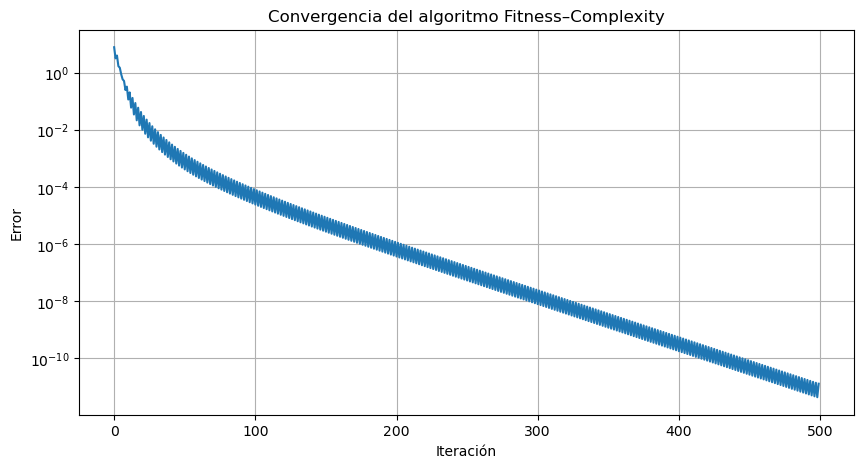

In [82]:
# Convergencia del modelo

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.semilogy(convergence)
plt.title("Convergencia del algoritmo Fitness–Complexity")
plt.xlabel("Iteración")
plt.ylabel("Error")
plt.grid(True)
plt.show()